# Imports and Data

In [ ]:
import pandas as pd
import os
from matplotlib import pyplot as plt
from tqdm import tqdm
import numpy as np
from utils import *
import importlib
# importlib.reload(utils)

# -------------------------------------------------------------

# Old Data

old_data_dir = "./data/DopantUptake/DopantUptake/Data"
old_samples = [os.path.join(old_data_dir, sample) for sample in os.listdir(old_data_dir)]

old_sample_dfs = {}
for sample in old_samples:
    sample_name = os.path.basename(sample).split('.')[0]
    old_sample_dfs[sample_name] = pd.read_csv(sample, sep='\t', skiprows=1, na_values=["Failed"])

def sorter(item):
    if item[0].startswith('Sample'):
        return int(item[0].split(' ')[-1])
    else: return 0

sample_dfs = dict( sorted(old_sample_dfs.items(), key=sorter) )

# Import thicknesses
thicknesses = pd.read_excel('./data/DopantUptake/DopantUptake/QCMSummary.xlsx', sheet_name='Thicknesses', index_col='Sample')

# New Data

new_data_dir = "./data/New/QCM-D data 03-12-2026"
mass_uptake_paths = {
    1: 'Sensor one 30% ortho-dichlorobenzene -70% toluene -150 C annealing processed.xlsx',             # Sample 81
    2: 'Sensor two 10% chlorobenzneen - 90% ortho-dichlorobenzene -150 C annealingprocessed.xlsx',      # Sample 21
    3: 'Sensor three 50% chlorobenzene - 50% ortho-dichlorobenzene _120 C annealing processed.xlsx'     # Sample 53
}
mass_uptake_paths = {
    sensor: os.path.join(new_data_dir, filename)
    for sensor, filename in mass_uptake_paths.items()
}
columns = [
        't [s]', 
        'dF3 sensor air reference', 
        'dF7 sensor air reference', 
        'dF9 sensor air reference',
        'dF13 sensor air reference',
        'dF3 sensor nBA reference', 
        'dF7 sensor nBA reference', 
        'dF9 sensor nBA reference',
        'dF13 sensor nBA reference',
        'dF Average',
        'dm3 [ng/cm2]',
        'dm7 [ng/cm2]',
        'dm9 [ng/cm2]',
        'dm13 [ng/cm2]',
        'dm Average [ng/cm2]'
]
mass_uptake_dfs = {}
for sensor in mass_uptake_paths:
    mass_uptake_dfs[sensor] = pd.read_excel(
        mass_uptake_paths[sensor], 
        sheet_name='Delta F and mass', 
        skiprows=3, 
        header=None, 
        names=columns, 
        na_values=["Failed"]
    )

# Sensor One (Sample 81)

In [13]:
mass_uptake_dfs[1]

,t [s],dF3 sensor air reference,dF7 sensor air reference,dF9 sensor air reference,dF13 sensor air reference,dF3 sensor nBA reference,dF7 sensor nBA reference,dF9 sensor nBA reference,dF13 sensor nBA reference,dF Average,dm3 [ng/cm3],dm7 [ng/cm3],dm9 [ng/cm3],dm13 [ng/cm3],dm Average [ng/cm3]
0,0.041872,0.147680,-0.163782,-0.155676,-0.146830,318.743827,229.338221,202.554936,170.428393,230.266344,-5641.765735,-4059.286508,-3585.222374,-3016.582560,-4075.714294
1,0.086172,0.192021,-0.160071,-0.145806,-0.140857,318.788167,229.341932,202.564806,170.434366,230.282318,-5642.550561,-4059.352188,-3585.397073,-3016.688283,-4075.997027
2,0.133075,0.185565,-0.156094,-0.157945,-0.141847,318.781711,229.345909,202.552667,170.433376,230.278416,-5642.436292,-4059.422581,-3585.182213,-3016.670759,-4075.927961
3,0.179363,0.199278,-0.161142,-0.149624,-0.132149,318.795425,229.340860,202.560988,170.443075,230.285087,-5642.679020,-4059.333231,-3585.329492,-3016.842428,-4076.046043
4,0.226404,0.173175,-0.146342,-0.148394,-0.136368,318.769322,229.355661,202.562218,170.438855,230.281514,-5642.216996,-4059.595203,-3585.351259,-3016.767738,-4075.982799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39633,1235.709308,-375.690938,-281.891354,-256.104433,-222.686189,-57.094791,-52.389351,-53.393821,-52.110966,-53.747232,1010.577802,927.291515,945.070627,922.364092,951.326009
39634,1235.734179,-375.784819,-281.767310,-254.678845,-222.305882,-57.188673,-52.265307,-51.968232,-51.730658,-53.288218,1012.239510,925.095933,919.837715,915.632653,943.201453
39635,1235.758115,-375.905688,-281.996405,-256.724650,-223.362091,-57.309541,-52.494403,-54.014037,-52.786867,-54.151212,1014.378876,929.150928,956.048462,934.327545,958.476453
39636,1235.782829,-375.549443,-282.012504,-255.880459,-223.454761,-56.953296,-52.510501,-53.169847,-52.879538,-53.878296,1008.073340,929.435876,941.106296,935.967820,953.645833


In [22]:
df_old = sample_dfs['Sample 81']
df_old

,Time [s],R1_m5 [ng/cm^2],C1_m [ng/cm^2]
0,0.0000,NaN,NaN
1,1.0064,NaN,NaN
2,2.0158,NaN,NaN
3,3.0235,NaN,NaN
4,4.0300,NaN,NaN
...,...,...,...
4058,1826.2635,1231.65,1209.11
4059,1826.7016,1231.30,1208.30
4060,1827.1659,1231.78,1210.06
4061,1827.6128,1233.89,1209.21


Text(0, 0.5, 'Sauerbrey Mass Uptake [ng/cm2]')

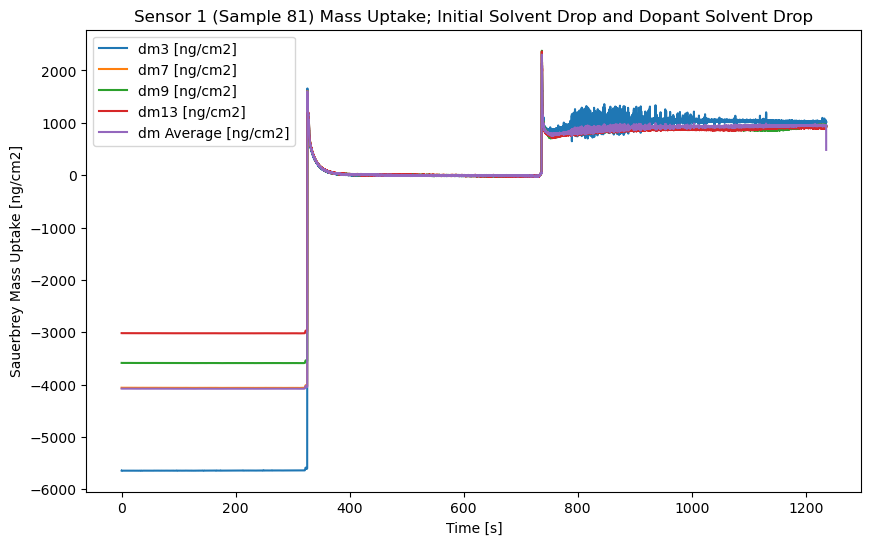

In [58]:
plt.figure(figsize=(10, 6))
df = mass_uptake_dfs[1]
for col in df.columns: 
    if col not in ['t [s]'] and col.startswith('dm'):
        plt.plot(df['t [s]'], df[col], label=col)

plt.legend()
plt.title('Sensor 1 (Sample 81) Mass Uptake; Initial Solvent Drop and Dopant Solvent Drop')
plt.xlabel('Time [s]')
plt.ylabel('Sauerbrey Mass Uptake [ng/cm2]')

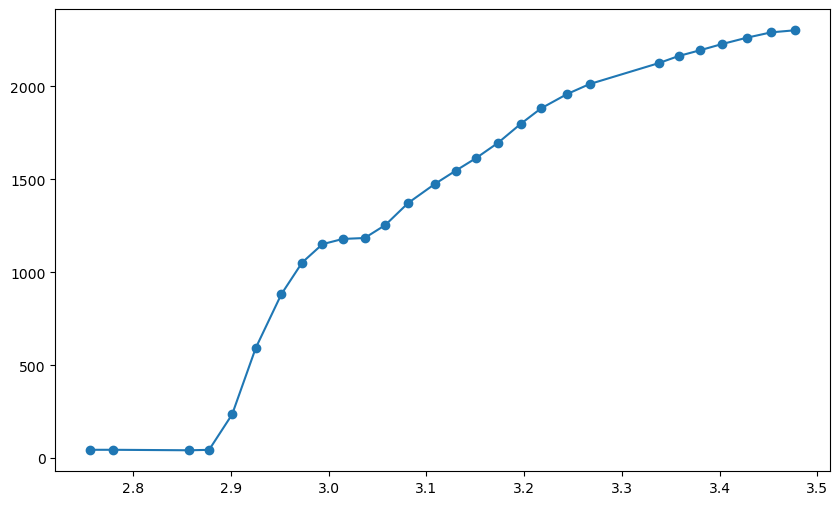

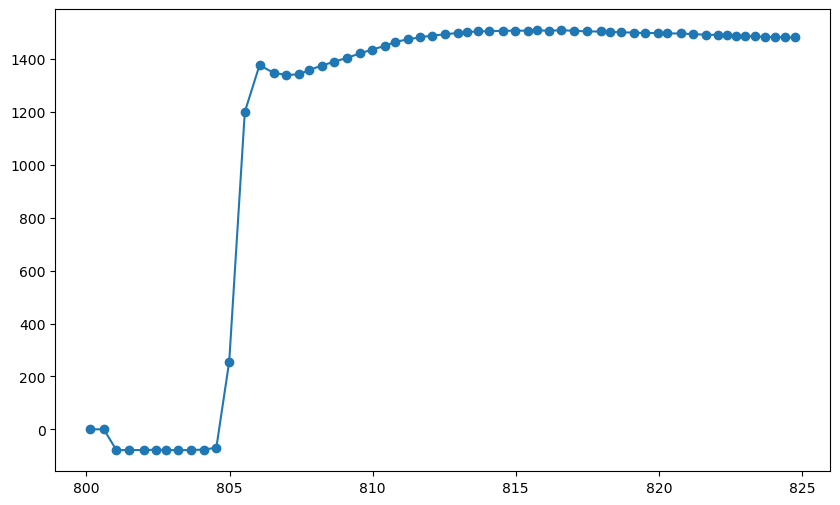

In [35]:
plt.figure(1, figsize=(10, 6))
df = mass_uptake_dfs[1]
df = df[df['t [s]'] > 600] # Crop out initial solvent drop
df = df[df['dm Average [ng/cm2]'] >= 0]
df['t shifted [s]'] = df['t [s]'] - df['t [s]'].iloc[0]
df = df[df['t shifted [s]'] <= 5] # Crop out long tail
df = df[df['t shifted [s]'].between(2.75, 3.5)]
plt.plot(df['t shifted [s]'], df['dm Average [ng/cm2]'], marker = 'o')


plt.figure(2, figsize=(10, 6))
df = sample_dfs['Sample 81']
df = df[df['Time [s]'].between(800, 825)]
plt.plot(df['Time [s]'], df['C1_m [ng/cm^2]'], marker = 'o')

C:\Users\willi\AppData\Local\Temp\ipykernel_5004\3177746049.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['slope'] = np.abs(np.gradient(df_new['dm Average [ng/cm2]'], df_new['t [s]']))
C:\Users\willi\AppData\Local\Temp\ipykernel_5004\3177746049.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['t shifted [s]'] = df_new['t [s]'] - df_new['t [s]'].loc[new_idx]
C:\Users\willi\AppData\Local\Temp\ipykernel_5004\3177746049.py:18: SettingWithCopyWarning: 
A value is trying to be set on a cop

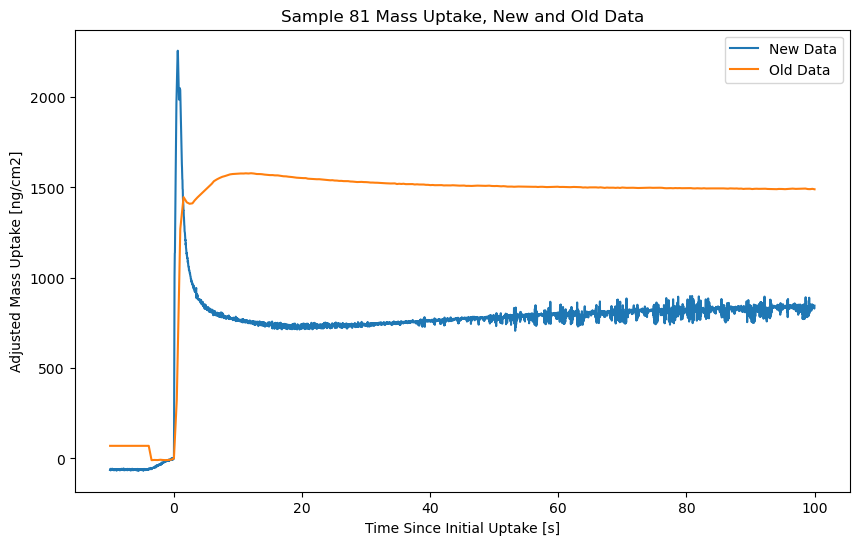

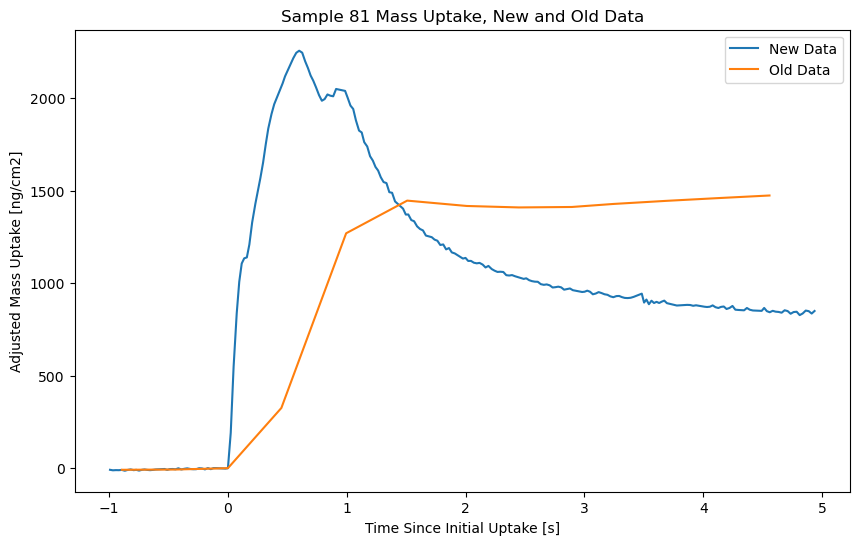

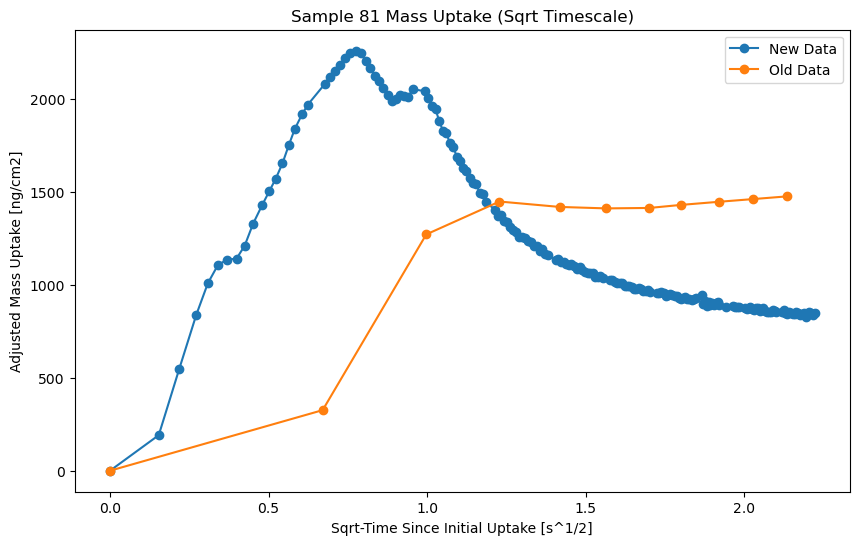

In [62]:
df_new = mass_uptake_dfs[1]
df_old = sample_dfs['Sample 81']

# Crop to initial uptake 
df_new = df_new[df_new['t [s]'] > 600] # Crop out initial solvent drop

df_new['slope'] = np.abs(np.gradient(df_new['dm Average [ng/cm2]'], df_new['t [s]']))
df_old['slope'] = np.abs(np.gradient(df_old['C1_m [ng/cm^2]'], df_old['Time [s]']))

new_thresh = 1000
old_thresh = 100

new_idx = df_new[df_new['slope'] > new_thresh].index[0]
old_idx = df_old[df_old['slope'] > old_thresh].index[0]

df_new['t shifted [s]'] = df_new['t [s]'] - df_new['t [s]'].loc[new_idx]
df_old['t shifted [s]'] = df_old['Time [s]'] - df_old['Time [s]'].loc[old_idx]
df_new['m shifted [ng/cm2]'] = df_new['dm Average [ng/cm2]'] - df_new['dm Average [ng/cm2]'].loc[new_idx]
df_old['m shifted [ng/cm2]'] = df_old['C1_m [ng/cm^2]'] - df_old['C1_m [ng/cm^2]'].loc[old_idx]

df_new = df_new[df_new['t shifted [s]'].between(-10, 100)]
df_old = df_old[df_old['t shifted [s]'].between(-10, 100)]

plt.figure(1, figsize=(10, 6))
plt.title('Sample 81 Mass Uptake, New and Old Data')
plt.plot(df_new['t shifted [s]'], df_new['m shifted [ng/cm2]'], label='New Data')
plt.plot(df_old['t shifted [s]'], df_old['m shifted [ng/cm2]'], label='Old Data')
plt.xlabel('Time Since Initial Uptake [s]')
plt.ylabel('Adjusted Mass Uptake [ng/cm2]')
plt.legend()


plt.figure(2, figsize=(10, 6))
plt.title('Sample 81 Mass Uptake, New and Old Data')

df_new = df_new[df_new['t shifted [s]'].between(-1, 5)]
df_old = df_old[df_old['t shifted [s]'].between(-1, 5)]

plt.plot(df_new['t shifted [s]'], df_new['m shifted [ng/cm2]'], label='New Data')
plt.plot(df_old['t shifted [s]'], df_old['m shifted [ng/cm2]'], label='Old Data')
plt.xlabel('Time Since Initial Uptake [s]')
plt.ylabel('Adjusted Mass Uptake [ng/cm2]')
plt.legend()


plt.figure(3, figsize=(10, 6))
plt.title('Sample 81 Mass Uptake (Sqrt Timescale)')
plt.plot(np.sqrt(df_new['t shifted [s]']), df_new['m shifted [ng/cm2]'], label='New Data', marker='o')
plt.plot(np.sqrt(df_old['t shifted [s]']), df_old['m shifted [ng/cm2]'], label='Old Data', marker='o')
plt.xlabel('Sqrt-Time Since Initial Uptake [s^1/2]')
plt.ylabel('Adjusted Mass Uptake [ng/cm2]')
plt.legend()

# Sensor Two (Sample 21)

Text(0, 0.5, 'Sauerbrey Mass Uptake [ng/cm2]')

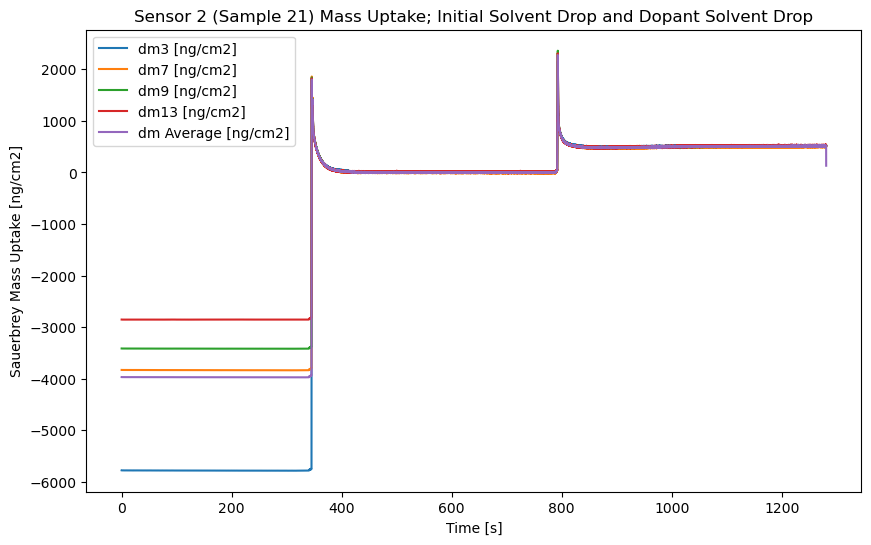

In [78]:
df_new = mass_uptake_dfs[2]
df_old = sample_dfs['Sample 21']

plt.figure(1, figsize=(10, 6))
for col in df_new.columns: 
    if col not in ['t [s]'] and col.startswith('dm'):
        plt.plot(df_new['t [s]'], df_new[col], label=col)

plt.legend()
plt.title('Sensor 2 (Sample 21) Mass Uptake; Initial Solvent Drop and Dopant Solvent Drop')
plt.xlabel('Time [s]')
plt.ylabel('Sauerbrey Mass Uptake [ng/cm2]')

C:\Users\willi\AppData\Local\Temp\ipykernel_5004\2294518938.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['slope'] = np.abs(np.gradient(df_new['dm Average [ng/cm2]'], df_new['t [s]']))
C:\Users\willi\AppData\Local\Temp\ipykernel_5004\2294518938.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['t shifted [s]'] = df_new['t [s]'] - df_new['t [s]'].loc[new_idx]
C:\Users\willi\AppData\Local\Temp\ipykernel_5004\2294518938.py:15: SettingWithCopyWarning: 
A value is trying to be set on a cop

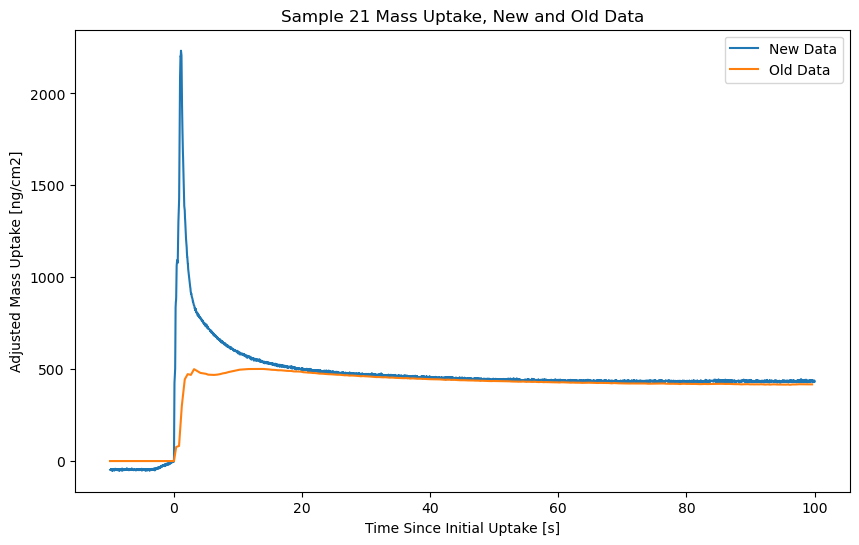

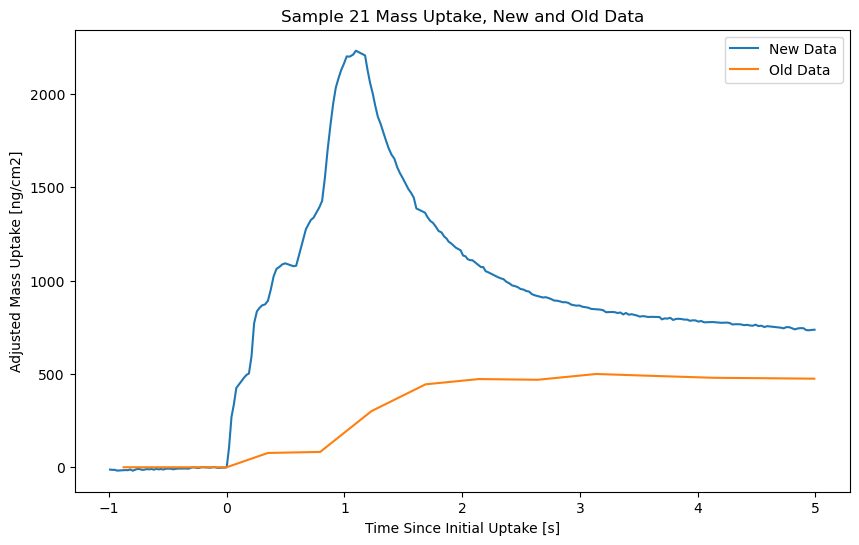

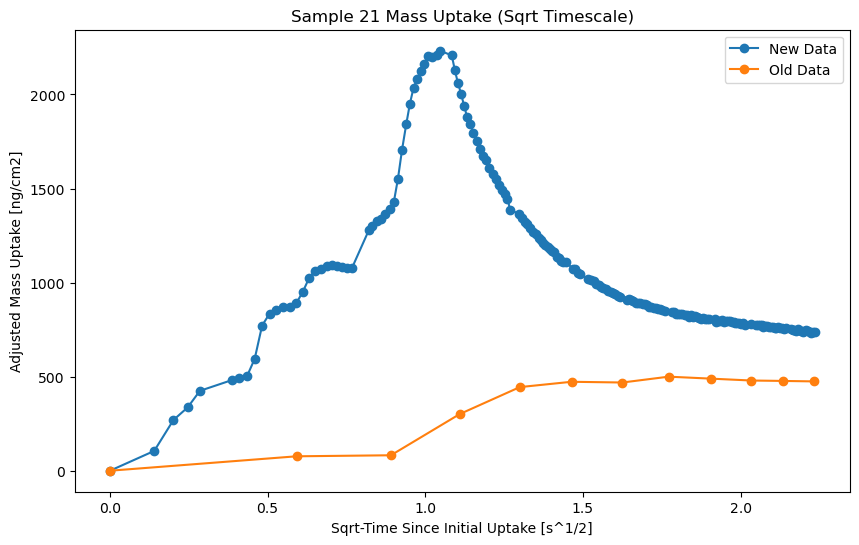

In [79]:
# Crop to initial uptake 
df_new = df_new[df_new['t [s]'] > 600] # Crop out initial solvent drop

df_new['slope'] = np.abs(np.gradient(df_new['dm Average [ng/cm2]'], df_new['t [s]']))
df_old['slope'] = np.abs(np.gradient(df_old['C1_m [ng/cm^2]'], df_old['Time [s]']))

new_thresh = 1000
old_thresh = 100

new_idx = df_new[df_new['slope'] > new_thresh].index[0]
old_idx = df_old[df_old['slope'] > old_thresh].index[0]

df_new['t shifted [s]'] = df_new['t [s]'] - df_new['t [s]'].loc[new_idx]
df_old['t shifted [s]'] = df_old['Time [s]'] - df_old['Time [s]'].loc[old_idx]
df_new['m shifted [ng/cm2]'] = df_new['dm Average [ng/cm2]'] - df_new['dm Average [ng/cm2]'].loc[new_idx]
df_old['m shifted [ng/cm2]'] = df_old['C1_m [ng/cm^2]'] - df_old['C1_m [ng/cm^2]'].loc[old_idx]

df_new = df_new[df_new['t shifted [s]'].between(-10, 100)]
df_old = df_old[df_old['t shifted [s]'].between(-10, 100)]

plt.figure(1, figsize=(10, 6))
plt.title('Sample 21 Mass Uptake, New and Old Data')
plt.plot(df_new['t shifted [s]'], df_new['m shifted [ng/cm2]'], label='New Data')
plt.plot(df_old['t shifted [s]'], df_old['m shifted [ng/cm2]'], label='Old Data')
plt.xlabel('Time Since Initial Uptake [s]')
plt.ylabel('Adjusted Mass Uptake [ng/cm2]')
plt.legend()


plt.figure(2, figsize=(10, 6))
plt.title('Sample 21 Mass Uptake, New and Old Data')

df_new = df_new[df_new['t shifted [s]'].between(-1, 5)]
df_old = df_old[df_old['t shifted [s]'].between(-1, 5)]

plt.plot(df_new['t shifted [s]'], df_new['m shifted [ng/cm2]'], label='New Data')
plt.plot(df_old['t shifted [s]'], df_old['m shifted [ng/cm2]'], label='Old Data')
plt.xlabel('Time Since Initial Uptake [s]')
plt.ylabel('Adjusted Mass Uptake [ng/cm2]')
plt.legend()


plt.figure(3, figsize=(10, 6))
plt.title('Sample 21 Mass Uptake (Sqrt Timescale)')
plt.plot(np.sqrt(df_new['t shifted [s]']), df_new['m shifted [ng/cm2]'], label='New Data', marker='o')
plt.plot(np.sqrt(df_old['t shifted [s]']), df_old['m shifted [ng/cm2]'], label='Old Data', marker='o')
plt.xlabel('Sqrt-Time Since Initial Uptake [s^1/2]')
plt.ylabel('Adjusted Mass Uptake [ng/cm2]')
plt.legend()

# Sensor 3 (Sample 53)

Text(0, 0.5, 'Sauerbrey Mass Uptake [ng/cm2]')

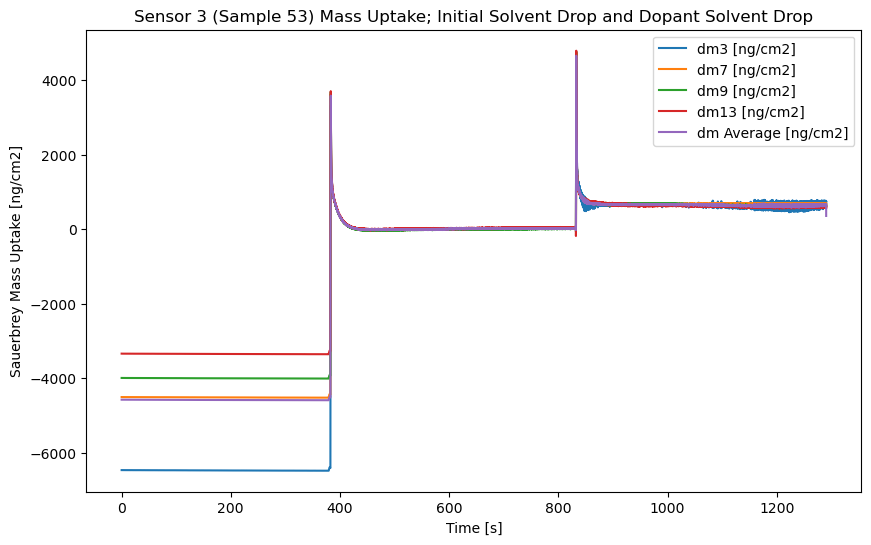

In [80]:
df_new = mass_uptake_dfs[3]
df_old = sample_dfs['Sample 53']

plt.figure(1, figsize=(10, 6))
for col in df_new.columns: 
    if col not in ['t [s]'] and col.startswith('dm'):
        plt.plot(df_new['t [s]'], df_new[col], label=col)

plt.legend()
plt.title('Sensor 3 (Sample 53) Mass Uptake; Initial Solvent Drop and Dopant Solvent Drop')
plt.xlabel('Time [s]')
plt.ylabel('Sauerbrey Mass Uptake [ng/cm2]')

C:\Users\willi\AppData\Local\Temp\ipykernel_5004\857441611.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['slope'] = np.abs(np.gradient(df_new['dm Average [ng/cm2]'], df_new['t [s]']))
C:\Users\willi\AppData\Local\Temp\ipykernel_5004\857441611.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['t shifted [s]'] = df_new['t [s]'] - df_new['t [s]'].loc[new_idx]
C:\Users\willi\AppData\Local\Temp\ipykernel_5004\857441611.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy o

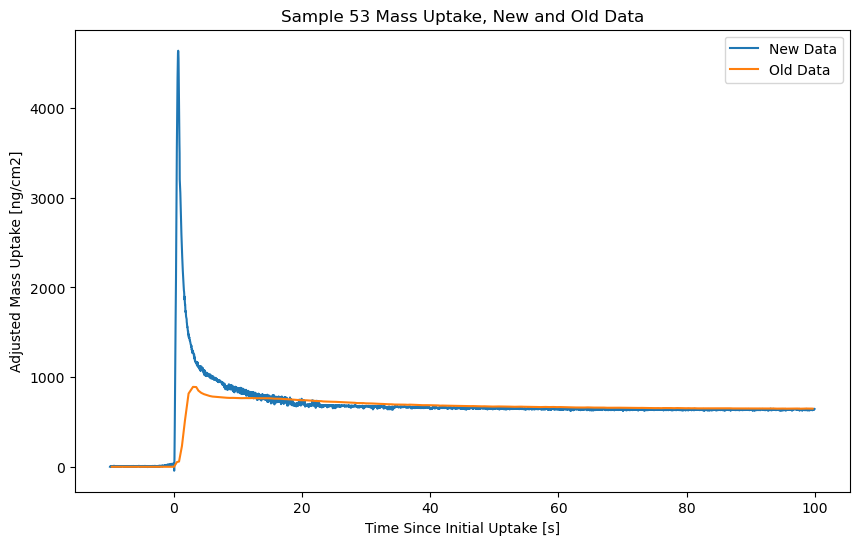

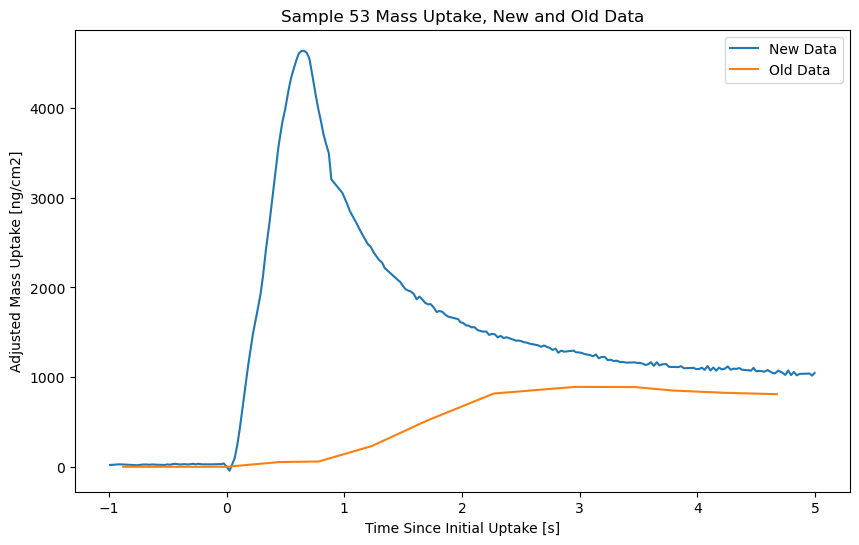

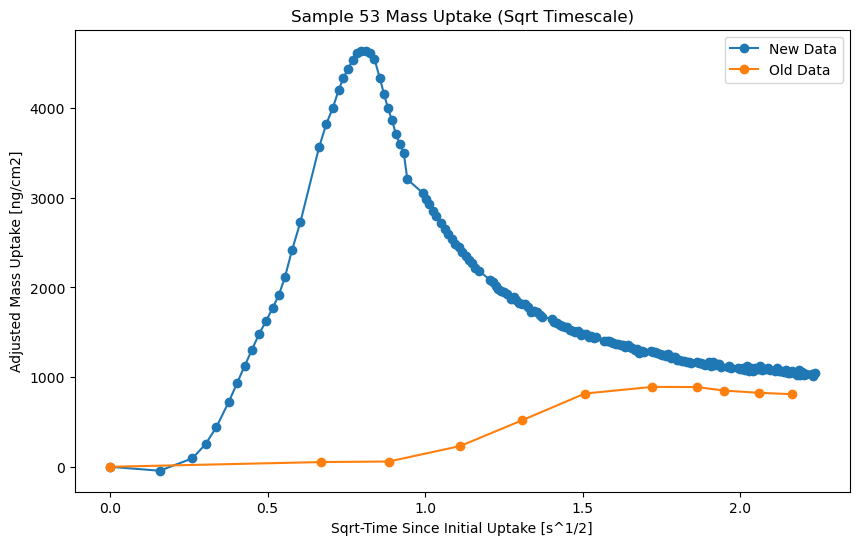

In [81]:
# Crop to initial uptake 
df_new = df_new[df_new['t [s]'] > 600] # Crop out initial solvent drop

df_new['slope'] = np.abs(np.gradient(df_new['dm Average [ng/cm2]'], df_new['t [s]']))
df_old['slope'] = np.abs(np.gradient(df_old['C1_m [ng/cm^2]'], df_old['Time [s]']))

new_thresh = 1000
old_thresh = 50

new_idx = df_new[df_new['slope'] > new_thresh].index[0]
old_idx = df_old[df_old['slope'] > old_thresh].index[0]

df_new['t shifted [s]'] = df_new['t [s]'] - df_new['t [s]'].loc[new_idx]
df_old['t shifted [s]'] = df_old['Time [s]'] - df_old['Time [s]'].loc[old_idx]
df_new['m shifted [ng/cm2]'] = df_new['dm Average [ng/cm2]'] - df_new['dm Average [ng/cm2]'].loc[new_idx]
df_old['m shifted [ng/cm2]'] = df_old['C1_m [ng/cm^2]'] - df_old['C1_m [ng/cm^2]'].loc[old_idx]

df_new = df_new[df_new['t shifted [s]'].between(-10, 100)]
df_old = df_old[df_old['t shifted [s]'].between(-10, 100)]

plt.figure(1, figsize=(10, 6))
plt.title('Sample 53 Mass Uptake, New and Old Data')
plt.plot(df_new['t shifted [s]'], df_new['m shifted [ng/cm2]'], label='New Data')
plt.plot(df_old['t shifted [s]'], df_old['m shifted [ng/cm2]'], label='Old Data')
plt.xlabel('Time Since Initial Uptake [s]')
plt.ylabel('Adjusted Mass Uptake [ng/cm2]')
plt.legend()


plt.figure(2, figsize=(10, 6))
plt.title('Sample 53 Mass Uptake, New and Old Data')

df_new = df_new[df_new['t shifted [s]'].between(-1, 5)]
df_old = df_old[df_old['t shifted [s]'].between(-1, 5)]

plt.plot(df_new['t shifted [s]'], df_new['m shifted [ng/cm2]'], label='New Data')
plt.plot(df_old['t shifted [s]'], df_old['m shifted [ng/cm2]'], label='Old Data')
plt.xlabel('Time Since Initial Uptake [s]')
plt.ylabel('Adjusted Mass Uptake [ng/cm2]')
plt.legend()


plt.figure(3, figsize=(10, 6))
plt.title('Sample 53 Mass Uptake (Sqrt Timescale)')
plt.plot(np.sqrt(df_new['t shifted [s]']), df_new['m shifted [ng/cm2]'], label='New Data', marker='o')
plt.plot(np.sqrt(df_old['t shifted [s]']), df_old['m shifted [ng/cm2]'], label='Old Data', marker='o')
plt.xlabel('Sqrt-Time Since Initial Uptake [s^1/2]')
plt.ylabel('Adjusted Mass Uptake [ng/cm2]')
plt.legend()

# Comparison

C:\Users\willi\AppData\Local\Temp\ipykernel_5004\1638579610.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['slope'] = np.abs(np.gradient(df_new['dm Average [ng/cm2]'], df_new['t [s]']))
C:\Users\willi\AppData\Local\Temp\ipykernel_5004\1638579610.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['t shifted [s]'] = df_new['t [s]'] - df_new['t [s]'].loc[new_idx]
C:\Users\willi\AppData\Local\Temp\ipykernel_5004\1638579610.py:29: SettingWithCopyWarning: 
A value is trying to be set on a co

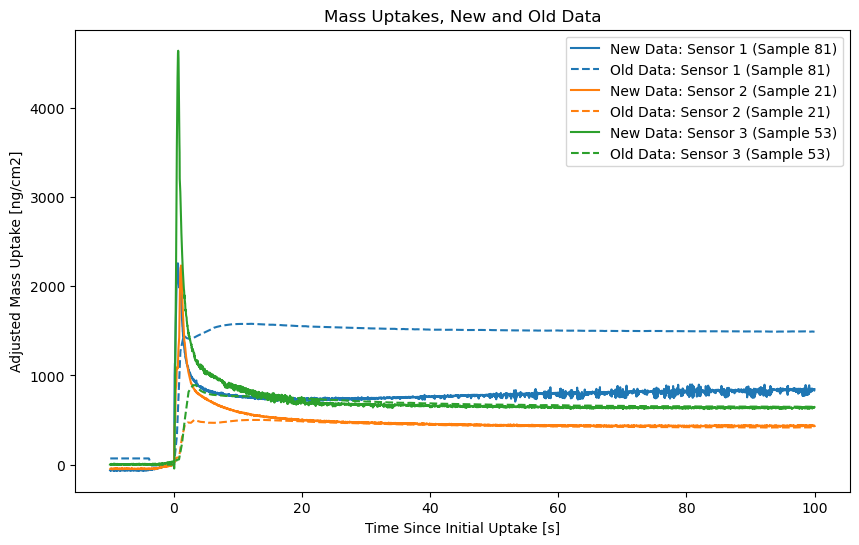

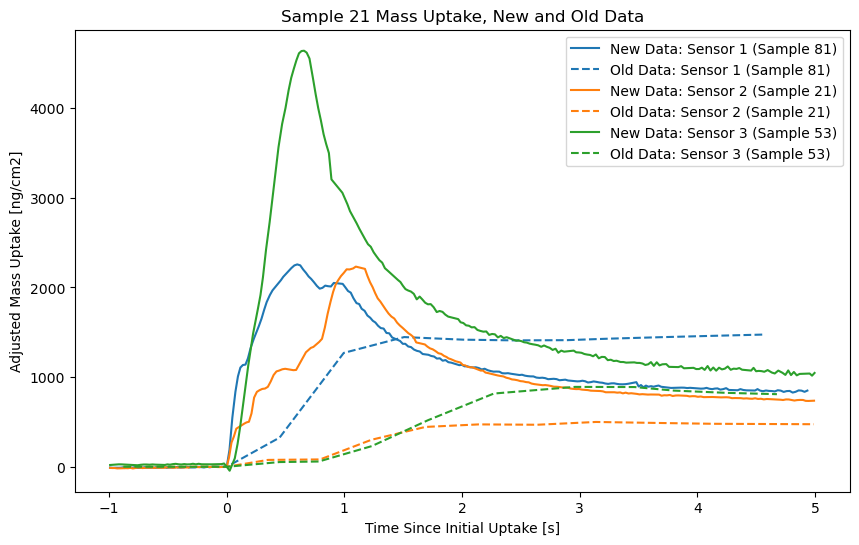

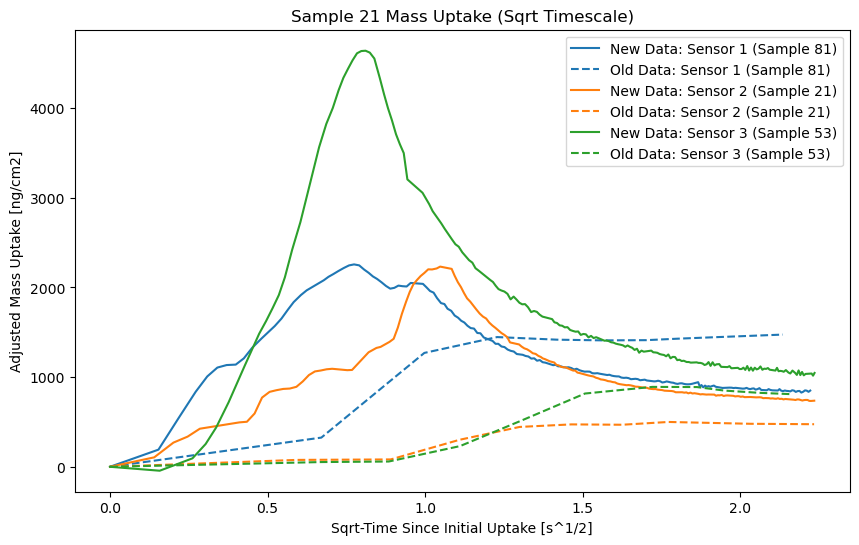

In [82]:
for sensor in mass_uptake_dfs:
    df_new = mass_uptake_dfs[sensor]
    if sensor == 1:
        sample_name = 'Sample 81'
        df_old = sample_dfs['Sample 81']
    elif sensor == 2:
        sample_name = 'Sample 21'
        df_old = sample_dfs['Sample 21']
    elif sensor == 3:
        sample_name = 'Sample 53'
        df_old = sample_dfs['Sample 53']
    
    df_new = df_new[df_new['t [s]'] > 600] # Crop out initial solvent drop

    df_new['slope'] = np.abs(np.gradient(df_new['dm Average [ng/cm2]'], df_new['t [s]']))
    df_old['slope'] = np.abs(np.gradient(df_old['C1_m [ng/cm^2]'], df_old['Time [s]']))

    new_thresh = 1000
    if sensor == 3:
        old_thresh = 50
    else:
        old_thresh = 100

    new_idx = df_new[df_new['slope'] > new_thresh].index[0]
    old_idx = df_old[df_old['slope'] > old_thresh].index[0]

    df_new['t shifted [s]'] = df_new['t [s]'] - df_new['t [s]'].loc[new_idx]
    df_old['t shifted [s]'] = df_old['Time [s]'] - df_old['Time [s]'].loc[old_idx]
    df_new['m shifted [ng/cm2]'] = df_new['dm Average [ng/cm2]'] - df_new['dm Average [ng/cm2]'].loc[new_idx]
    df_old['m shifted [ng/cm2]'] = df_old['C1_m [ng/cm^2]'] - df_old['C1_m [ng/cm^2]'].loc[old_idx]

    df_new = df_new[df_new['t shifted [s]'].between(-10, 100)]
    df_old = df_old[df_old['t shifted [s]'].between(-10, 100)]

    plt.figure(1, figsize=(10, 6))
    plt.title('Mass Uptakes, New and Old Data')
    line, = plt.plot(df_new['t shifted [s]'], df_new['m shifted [ng/cm2]'], label=f'New Data: Sensor {sensor} ({sample_name})')
    plt.plot(df_old['t shifted [s]'], df_old['m shifted [ng/cm2]'], label=f'Old Data: Sensor {sensor} ({sample_name})', linestyle='--', color=line.get_color())
    plt.xlabel('Time Since Initial Uptake [s]')
    plt.ylabel('Adjusted Mass Uptake [ng/cm2]')
    plt.legend()


    plt.figure(2, figsize=(10, 6))
    plt.title('Sample 21 Mass Uptake, New and Old Data')

    df_new = df_new[df_new['t shifted [s]'].between(-1, 5)]
    df_old = df_old[df_old['t shifted [s]'].between(-1, 5)]

    line, = plt.plot(df_new['t shifted [s]'], df_new['m shifted [ng/cm2]'], label=f'New Data: Sensor {sensor} ({sample_name})')
    plt.plot(df_old['t shifted [s]'], df_old['m shifted [ng/cm2]'], label=f'Old Data: Sensor {sensor} ({sample_name})', linestyle='--', color=line.get_color())
    plt.xlabel('Time Since Initial Uptake [s]')
    plt.ylabel('Adjusted Mass Uptake [ng/cm2]')
    plt.legend()


    plt.figure(3, figsize=(10, 6))
    plt.title('Sample 21 Mass Uptake (Sqrt Timescale)')
    plt.plot(np.sqrt(df_new['t shifted [s]']), df_new['m shifted [ng/cm2]'], label=f'New Data: Sensor {sensor} ({sample_name})')
    plt.plot(np.sqrt(df_old['t shifted [s]']), df_old['m shifted [ng/cm2]'], label=f'Old Data: Sensor {sensor} ({sample_name})', linestyle='--', color=line.get_color())
    plt.xlabel('Sqrt-Time Since Initial Uptake [s^1/2]')
    plt.ylabel('Adjusted Mass Uptake [ng/cm2]')
    plt.legend()